In [28]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [29]:
data_path = "tweets-data\sentiment-italia.csv"
prepro_data_path = "tweets-data\hasilpreprocess-italia.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_5948\404684709.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-italia.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_5948\404684709.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-italia.csv"


In [30]:
data = pd.read_csv(data_path)

In [31]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893729455157244084,Sun Feb 23 18:36:23 +0000 2025,0,@kenafricx21 Unaijua Manchester united anko?,1893731646622376172,NaN,kenafricx21,it,NaN,0,1,0,https://x.com/kasimuabuu98/status/189373164662...,1531168792507736064,kasimuabuu98
1,1893730064111382764,Sun Feb 23 18:30:05 +0000 2025,0,Unomudi mkomana ano support Manchester United ...,1893730064111382764,NaN,NaN,it,NaN,0,0,0,https://x.com/Suavefloew/status/18937300641113...,1867144816875692032,Suavefloew
2,1893728569970335962,Sun Feb 23 18:24:09 +0000 2025,0,Il Manchester United è la dimostrazione per cu...,1893728569970335962,NaN,NaN,it,Friuli-Venezia Giulia,0,0,0,https://x.com/Redblack100x100/status/189372856...,2333536199,Redblack100x100
3,1893723464587964540,Sun Feb 23 18:03:52 +0000 2025,0,Manchester United é DECIMO QUINTO colocado da ...,1893723464587964540,NaN,NaN,it,"Rua Mariano Procópio, 37",0,0,0,https://x.com/Leorz8/status/1893723464587964540,170414429,Leorz8
4,1893676632679821535,Sun Feb 23 17:35:31 +0000 2025,0,@JMariotz @miguuyamjeruman Manchester United u...,1893716329099624535,NaN,JMariotz,it,NaN,0,0,0,https://x.com/NovatyM27250/status/189371632909...,1699834656340996096,NovatyM27250


In [32]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,@kenafricx21 Unaijua Manchester united anko?,kasimuabuu98,Sun Feb 23 18:36:23 +0000 2025
1,Unomudi mkomana ano support Manchester United ...,Suavefloew,Sun Feb 23 18:30:05 +0000 2025
2,Il Manchester United è la dimostrazione per cu...,Redblack100x100,Sun Feb 23 18:24:09 +0000 2025
3,Manchester United é DECIMO QUINTO colocado da ...,Leorz8,Sun Feb 23 18:03:52 +0000 2025
4,@JMariotz @miguuyamjeruman Manchester United u...,NovatyM27250,Sun Feb 23 17:35:31 +0000 2025
...,...,...,...
562,@connectwithtola @nwabishop 1. Manchester Unit...,ChukwuebukaX002,Thu Feb 06 18:58:49 +0000 2025
563,@connectwithtola @nwabishop Manchester United ...,OkanlawonAyo,Thu Feb 06 18:56:21 +0000 2025
564,@connectwithtola @nwabishop Manchester United ...,MartinsUch51622,Thu Feb 06 18:46:06 +0000 2025
565,@connectwithtola @nwabishop Manchester United ...,Jennifer_Ezepue,Thu Feb 06 18:41:11 +0000 2025


# 1. Cleaning Data

In [33]:
df = df.drop_duplicates(subset=['full_text'])

In [34]:
df.duplicated().sum()

0

In [35]:
df = df.dropna()

In [36]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [37]:
df.shape

(564, 3)

In [38]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [39]:
df['full_text'] = df['full_text'].str.lower()

In [40]:
df

,full_text,username,created_at
0,unaijua manchester united anko,kasimuabuu98,Sun Feb 23 18:36:23 +0000 2025
1,unomudi mkomana ano support manchester united ...,Suavefloew,Sun Feb 23 18:30:05 +0000 2025
2,il manchester united la dimostrazione per cui ...,Redblack100x100,Sun Feb 23 18:24:09 +0000 2025
3,manchester united decimo quinto colocado da pr...,Leorz8,Sun Feb 23 18:03:52 +0000 2025
4,manchester united usiseme kidogo ni unaiongele...,NovatyM27250,Sun Feb 23 17:35:31 +0000 2025
...,...,...,...
562,1 manchester united 31 leicester city 2 como 0...,ChukwuebukaX002,Thu Feb 06 18:58:49 +0000 2025
563,manchester united 2 2 leicester city como 2 2 ...,OkanlawonAyo,Thu Feb 06 18:56:21 +0000 2025
564,manchester united 42 leicester como 22 juventus,MartinsUch51622,Thu Feb 06 18:46:06 +0000 2025
565,manchester united 2 vs 1 leicester city como 0...,Jennifer_Ezepue,Thu Feb 06 18:41:11 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [41]:
data = pd.read_csv(prepro_data_path, encoding='latin1')

# 3. Labeling

In [42]:
data

,full_text
0,"['unaijua', 'manchester', 'united', 'anko']"
1,"['unomudi', 'mkomana', 'ano', 'support', 'manc..."
2,"['manchester', 'united', 'dimostrazione', 'mil..."
3,"['manchester', 'united', 'decimo', 'quinto', '..."
4,"['manchester', 'united', 'usiseme', 'kidogo', ..."
...,...
559,"['1', 'manchester', 'united', '31', 'leicester..."
560,"['manchester', 'united', '2', '2', 'leicester'..."
561,"['manchester', 'united', '42', 'leicester', 'c..."
562,"['manchester', 'united', '2', 'vs', '1', 'leic..."


In [43]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 59
Netral = 487
Negatif = 18

Total Data : 564


In [45]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['unaijua', 'manchester', 'united', 'anko']",Netral
1,"['unomudi', 'mkomana', 'ano', 'support', 'manc...",Netral
2,"['manchester', 'united', 'dimostrazione', 'mil...",Positif
3,"['manchester', 'united', 'decimo', 'quinto', '...",Netral
4,"['manchester', 'united', 'usiseme', 'kidogo', ...",Netral
...,...,...
559,"['1', 'manchester', 'united', '31', 'leicester...",Netral
560,"['manchester', 'united', '2', '2', 'leicester'...",Netral
561,"['manchester', 'united', '42', 'leicester', 'c...",Netral
562,"['manchester', 'united', '2', 'vs', '1', 'leic...",Netral


# 4. Visualisasi

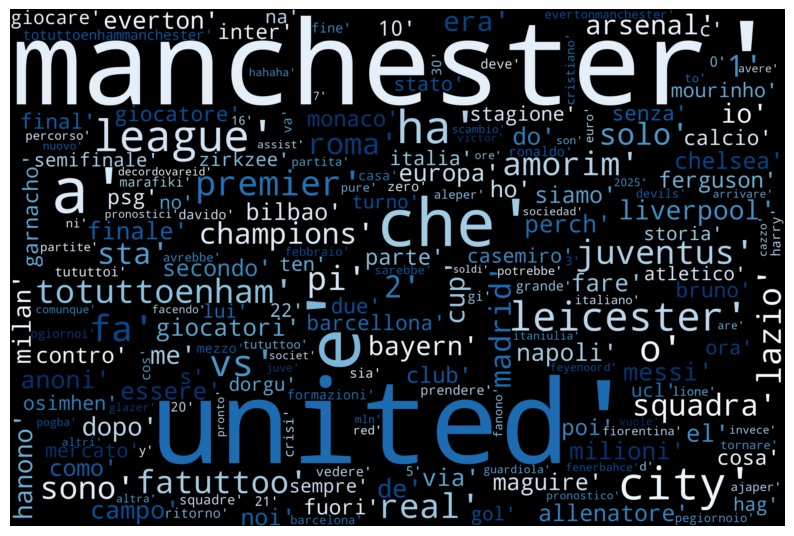

In [46]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

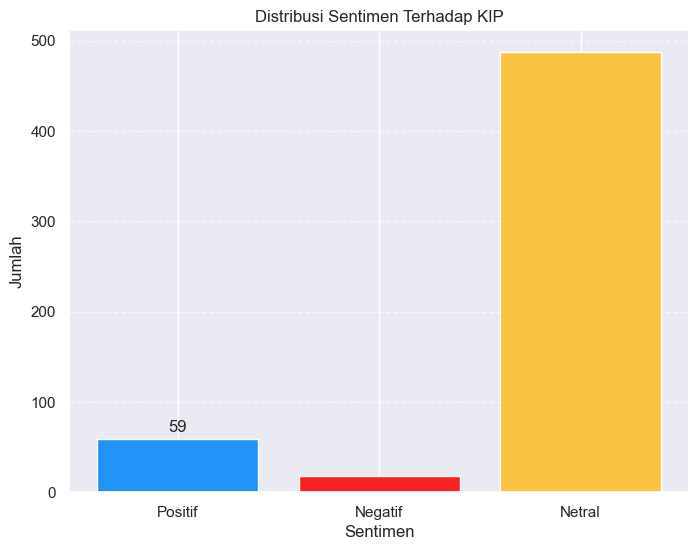

In [47]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Support Vector Machine (SVM)

In [48]:
import numpy as np
import pandas as pd

import re
from nltk.corpus import stopwords

In [49]:
data

,full_text,klasifikasi
0,"['unaijua', 'manchester', 'united', 'anko']",Netral
1,"['unomudi', 'mkomana', 'ano', 'support', 'manc...",Netral
2,"['manchester', 'united', 'dimostrazione', 'mil...",Positif
3,"['manchester', 'united', 'decimo', 'quinto', '...",Netral
4,"['manchester', 'united', 'usiseme', 'kidogo', ...",Netral
...,...,...
559,"['1', 'manchester', 'united', '31', 'leicester...",Netral
560,"['manchester', 'united', '2', '2', 'leicester'...",Netral
561,"['manchester', 'united', '42', 'leicester', 'c...",Netral
562,"['manchester', 'united', '2', 'vs', '1', 'leic...",Netral


In [50]:
print(len(data.klasifikasi.unique()))
print(len(data))

3
564


In [51]:
print(data.groupby('klasifikasi').size())

klasifikasi
Negatif     18
Netral     487
Positif     59
dtype: int64


In [52]:
labels = data.klasifikasi.values
text = data.full_text.values

In [53]:
labels

array(['Netral', 'Netral', 'Positif', 'Netral', 'Netral', 'Netral',
       'Positif', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Netral', 'Netral', 'Netral', 'Positif',
       'Positif', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Positif', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Positif', 'Netral', 'Netral', 'Netral', 'Netral',
       'Positif', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Negatif', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Netral', 'Netral', 'Netral', 'Netral',
       'Positif', 'Netral', 'Negatif', 'Netral', 'Netral', 'Netral',
       'Netral', 'Netral', 'Positif', 'Netral', 'Net

In [54]:
text

array(["['unaijua', 'manchester', 'united', 'anko']",
       "['unomudi', 'mkomana', 'ano', 'support', 'manchester', 'united', 'city']",
       "['manchester', 'united', 'dimostrazione', 'milan', 'basta', 'spendere', 'soldi', 'bisogna', 'avere', 'societ', 'dietro', 'che', 'sia', 'vicino', 'squadra', 'no', 'faremmo', 'fine', 'qui', 'colpa', 'solo', 'giocatori', 'e', 'allenatore', 'problema', 'sta', 'a', 'monte']",
       "['manchester', 'united', 'decimo', 'quinto', 'colocado', 'premier', 'league']",
       "['manchester', 'united', 'usiseme', 'kidogo', 'ni', 'unaiongelea', 'sana']",
       "['manchester', 'united', 'riu', 'disso']",
       "['devi', 'avere', 'pure', 'allenatore', 'che', 'approva', 'invece', 'voleva', 'giocatuttoolino', 'manchester', 'united', 'bloccandoci', 'mercato']",
       "['bonera', 'cosa', 'deve', 'fare', 'essere', 'cacciato', 'milan', 'a', 'incompetenza', 'unicum', 'mondo', 'calcio', 'forse', 'solo', 'manchester', 'united', 'livello', 'schifo']",
       "['manc

In [55]:
texts = []

for i in range(0, len(text)):
    tweet = re.sub('@([A-Za-z0-9_]+)', ' ', text[i]) # replace usernames with a whitespace
    tweet = re.sub('http([:/A-Za-z0-9_.]+)', ' ', tweet) # replace urls with a whitespace
    tweet = re.sub('www([:/A-Za-z0-9_.]+)', ' ', tweet) # replace urls with a whitespace
    tweet = re.sub('[^a-zA-Z0-9.:_!?\-\(\)]', ' ', tweet) # replace everything that is not in the selection with a whitespac
    tweet = re.sub('(\s+)', ' ', tweet).lower().split() # replace multiple whitespaces with one whitespace, lowercase everything
    tweet = [word for word in tweet if not word in set(stopwords.words('italian'))] # remove stopwords
    tweet = ' '.join(tweet)
    texts.append(tweet)

<>:7: SyntaxWarning: invalid escape sequence '\-'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\-'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Asus\AppData\Local\Temp\ipykernel_5948\397736204.py:7: SyntaxWarning: invalid escape sequence '\-'
  tweet = re.sub('[^a-zA-Z0-9.:_!?\-\(\)]', ' ', tweet) # replace everything that is not in the selection with a whitespac
C:\Users\Asus\AppData\Local\Temp\ipykernel_5948\397736204.py:8: SyntaxWarning: invalid escape sequence '\s'
  tweet = re.sub('(\s+)', ' ', tweet).lower().split() # replace multiple whitespaces with one whitespace, lowercase everything


In [56]:
texts

['unaijua manchester united anko',
 'unomudi mkomana ano support manchester united city',
 'manchester united dimostrazione milan basta spendere soldi bisogna avere societ dietro vicino squadra no fine qui colpa solo giocatori allenatore problema monte',
 'manchester united decimo quinto colocado premier league',
 'manchester united usiseme kidogo ni unaiongelea sana',
 'manchester united riu disso',
 'devi avere pure allenatore approva invece voleva giocatuttoolino manchester united bloccandoci mercato',
 'bonera cosa deve fare essere cacciato milan incompetenza unicum mondo calcio forse solo manchester united livello schifo',
 'manchester united za ta rage aikata',
 'diao classico giocatore manchester united paga 75 milioni giugno',
 'aleper ferguson manchester united guardiola manchester city',
 'manchester united na intermiami',
 'manchester united italiano metuttoetevi cuore pace',
 'rischiare scendere no stupirei vedere milan stabilmente posizioni manchester united atuttouale',
 

In [57]:
from sklearn.feature_extraction.text import CountVectorizer
X = texts
y = labels

cv = CountVectorizer(max_features = 5000) # choose the max number of features carefully
X = cv.fit_transform(X).toarray()
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [58]:
occ = np.asarray(X.sum(axis=0)).ravel().tolist()
counts_df = pd.DataFrame({'term': cv.get_feature_names_out(), 'occurrences': occ})
counts_df.sort_values(by='occurrences', ascending=False).head(20)

,term,occurrences
1256,manchester,557
2228,united,552
466,city,46
1169,league,43
1175,leicester,36
2338,vs,31
764,fa,29
1657,premier,27
1762,real,26
1584,pi,25


In [59]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X = tfidf.fit_transform(X).toarray()

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0) # shuffle is by default true

In [61]:
from sklearn import svm

clf = svm.SVC()
clf.fit(X_train, y_train)  

SVC()

In [62]:
y_pred = clf.predict(X_test)

In [63]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='micro')  # or 'micro', 'weighted'
print("f1 score : ",f1)

f1 score :  0.9026548672566371


In [64]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create a dictionary with a range of parameter values for C, gamma and the kernel
parameters = {'C': [0.01, 0.1, 1], # default: 1.0
          'gamma': [0.001, 0.01, 0.1], # default: auto
          'kernel':['sigmoid','rbf'] }

svc = SVC()
clf = GridSearchCV(svc, parameters)

# Fit the data with the best possible parameters
clf.fit(X_train, y_train)

#Print the best estimator with its parameters
print(clf.best_params_)

{'C': 0.01, 'gamma': 0.001, 'kernel': 'sigmoid'}


C:\Users\Asus\AppData\Local\Temp\ipykernel_5948\754329288.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_counts, x='Sentiment', y='Count', palette='viridis')


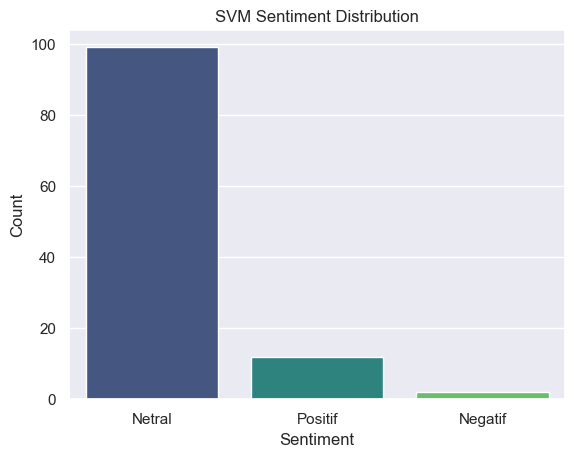

In [65]:
# Convert predictions to DataFrame for easier plotting
pred_df = pd.DataFrame(y_test, columns=['Sentiment'])

# Count the frequency of each sentiment
sentiment_counts = pred_df['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create the bar plot
sns.barplot(data=sentiment_counts, x='Sentiment', y='Count', palette='viridis')
plt.title('SVM Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()